In [98]:
%%latex

UsageError: %%latex is a cell magic, but the cell body is empty.


In [18]:
from scipy.special import gamma
from scipy.integrate import quad
from cmath import sqrt as csqrt
# import spherical harmonics
from scipy.special import sph_harm
# multiple line output
from IPython.core.interactiveshell import InteractiveShell
import numpy as np
from functools import lru_cache
from collections import defaultdict

from functools import lru_cache
from sympy import S
from sympy.physics.wigner import wigner_3j

In [69]:
InteractiveShell.ast_node_interactivity = "all"

In [4]:
#import Decimal
from decimal import Decimal

In [5]:
rp = 1.
q =  2/100.
h0 = 0.5 + csqrt(0.25 - q**2) # h w/ L=0
iq = 1j*q
Q = 1.

In [28]:
# def complex conjugate of a function
def bar(f):
    """
    Calculate the complex conjugate of a function.
    """
    return np.conj(f)

def h(l):
    d2 = 0.25 + l*(l+1) - q**2
    if d2 > 0:
        return 0.5 + csqrt(d2)
    else:
        return 0.5 - csqrt(d2)

# QNM frequencies

In [ ]:
def s(n, l):
    """
    qnm frequency in the variable s=-i\omega
    """
    return - (n + h(l) + iq) / 2.


def w(n, l):
    """
    qnm frequency in the variable s=-i\omega
    """
    return -1j * (n + h(l) + iq) / 2.

In [29]:
def poch(a,n):
    """
    Pochhammer symbol
    """
    if type(n) == int:
        return (-1)**n * gamma(1-a)/gamma(1-a-n)
    else:
        return gamma(a+n)/gamma(a)

# Q coefficients

In [30]:
@lru_cache(None)
def W3j(j1, j2, j3, m1, m2, m3):
    """
    Cached Wigner 3j symbol.

    Uses SymPy's exact implementation internally, then converts to float.
    """

    # Selection rule
    if m1 + m2 + m3 != 0:
        return 0.0

    # Magnetic bounds
    if abs(m1) > j1 or abs(m2) > j2 or abs(m3) > j3:
        return 0.0

    # Triangle inequality
    if j3 < abs(j1 - j2) or j3 > j1 + j2:
        return 0.0

    return float(wigner_3j(
        S(j1), S(j2), S(j3),
        S(m1), S(m2), S(m3)
    ))

In [31]:
W3j(0,0,0,0,0,0)

1.0

In [48]:
# gaunt integral integral in terms of Wigner 3j symbols
def gaunt(l1,l2,l3,m1,m2,m3):
    """
    Calculate the Gaunt integral using the Wigner 3j symbols.
    """
    return np.sqrt((2*l1+1)*(2*l2+1)*(2*l3+1)/(4*np.pi))*W3j(l1,l2,l3,0,0,0)*W3j(l1,l2,l3,m1,m2,m3)

def Q_element(li, mi, lj, mj, lk, mk, lp, mp):
    """
    Compute

        Q^{ij}_{kp} = ∫_{S^2} dΩ Y_i Y_j \bar{Y}_k \bar{Y}_p

    using the Wigner-3j formula

        Q^{ij}_{kp}
        =
        sum_l (-1)^{m + mk + mp}
        (2l+1)/(4π)
        sqrt[(2li+1)(2lj+1)(2lk+1)(2lp+1)]
        *
        (li lj l; 0 0 0)
        (li lj l; mi mj -m)
        (lk lp l; 0 0 0)
        (lk lp l; -mk -mp m)

    where m = mi + mj = mk + mp.
    """

    # Magnetic selection rule
    if mi + mj != mk + mp:
        return 0.0

    m = mi + mj

    # Triangle bounds from both pairs, plus |m| <= l.
    ell_min = max(abs(li - lj), abs(lk - lp), abs(m))
    ell_max = min(li + lj, lk + lp)

    if ell_min > ell_max:
        return 0.0

    pref = np.sqrt(
        (2*li + 1) *
        (2*lj + 1) *
        (2*lk + 1) *
        (2*lp + 1)
    ) / (4*np.pi)

    phase = (-1)**(m + mk + mp)

    total = 0.0

    for ell in range(ell_min, ell_max + 1):

        # Optional parity shortcuts:
        # (l1 l2 ell; 0 0 0) vanishes unless l1+l2+ell is even.
        if (li + lj + ell) % 2 != 0:
            continue
        if (lk + lp + ell) % 2 != 0:
            continue

        term = (
            phase
            * (2*ell + 1)
            * pref
            * W3j(li, lj, ell, 0, 0, 0)
            * W3j(li, lj, ell, mi, mj, -m)
            * W3j(lk, lp, ell, 0, 0, 0)
            * W3j(lk, lp, ell, -mk, -mp, m)
        )

        total += term

    return total


In [49]:
Q_element(0, 0, 0, 0, 0, 0, 0, 0)

0.07957747154594767

# near-zone radial coefficients

In [51]:
def Anorm(n,l):
    tmp = (  1j * (-1.)**(h(l)+iq) * 2. * gamma(n+1.) * gamma(2*h(l)+n) * gamma(1-h(l)-n-iq)  ) / ( gamma(h(l)-iq) * poch(h(l)+iq,n) )
    return csqrt(tmp)

In [52]:
Anorm(2,10)

(4598.718144782148-18.35628533183092j)

In [53]:
def P(j,n,ell):
    return poch(-n, j) * poch(1-2*h(ell)-n, j) / ( gamma(j+1)*poch(1-h(ell)-n-iq,j) )

def PLM(j, k1):
    return poch(-k1['n'], j) * poch(1-2*h(k1['l'])-k1['n'], j) / ( gamma(j+1)*poch(1-h(k1['l'])-k1['n']-iq,j) )

def P2(k,n,m,ell):
    tmp = 0
    for j in range(0, k+1):
        tmp += P(k-j,n,ell)*P(j,m,ell)
    return tmp

def P3(i,n,m,p,ell):
    tmp = 0
    for j in range(0, i+1):
        tmp += P2(j,p,m,ell)*bar(P(i-j,n,ell))
    return tmp

def P4(i,n,m,p,q,ell):
    tmp = 0
    for j in range(0, i+1):
        tmp += P3(j,q,p,m,ell)*P(i-j,n,ell)
    return tmp

def P2LMn(k, k1, k2):
    tmp = 0
    for j in range(0, k+1):
        tmp += PLM(k-j,k1)*PLM(j,k2)
    return tmp

def P3LMn(i, k1, k2, k3):
    tmp = 0
    for j in range(0, i+1):
        tmp += P2LM(j,k3,k2)*bar(PLM(i-j,k1))
    return tmp

def P4LMn(i, k1, k2, k3, K):
    tmp = 0
    for j in range(0, i+1):
        tmp += P3LM(j,K,k3,k2)*PLM(i-j,k1)
    return tmp

def P2LM(k, k1, k2):
    tmp = 0
    for j in range(0, k+1):
        tmp += PLM(k-j,k1)*PLM(j,k2)
    return tmp

def P3LM(i, k1, k2, k3):
    tmp = 0
    for j in range(0, i+1):
        tmp += P2LM(j,k1,k2)*bar(PLM(i-j,k3))
    return tmp

def P4LM(i, k1, k2, k3, K):
    tmp = 0
    for j in range(0, i+1):
        tmp += P3LM(j,k1,k2,k3)*PLM(i-j,K)
    return tmp


In [54]:
P4LMn(10,({ 'n': 10, 'l': 1}), ({ 'n': 30, 'l': 1}), ({ 'n': 20, 'l': 1}), ({ 'n': 1, 'l': 1}))

(268669768990.13318-1636243009.5837204j)

In [55]:
P4(10,10,30,20,1,1)

(268667724444.19-2001697937.4323893j)

In [62]:
@lru_cache(None)
def PLM_cached(j, n, ell):
    return (
        poch(-n, j)
        * poch(1 - 2*h(ell) - n, j)
        / (gamma(j + 1) * poch(1 - h(ell) - n - iq, j))
    )


def PLM(j, mode):
    return PLM_cached(j, mode["n"], mode["l"])

In [91]:
def C_abcd(i, a, b, c, d):
    """
    Coefficient C_i^{(a,b,c,d)} with the barred slot b as in the paper
    """

    total = 0

    for j in range(i + 1):
        for k in range(j + 1):
            for ell in range(k + 1):
                total += (
                    PLM(i - j, a)
                    * bar(PLM(j - k, b))
                    * PLM(k - ell, c)
                    * PLM(ell, d)
                )

    return total

def P4LMn_as_C_abcd(i, a, b, c, d):
    return P4LMn(i, a, b, d, c)

In [92]:
A = {'n': 10, 'l': 1}
B = {'n': 30, 'l': 1}
C = {'n': 20, 'l': 1}
D = {'n': 1,  'l': 1}

x = C_abcd(10, A, B, C, D)
y = P4LMn_as_C_abcd(10, A, B, C, D)

print(x)
print(y)
print(x - y)

(268669768990.13312-1636243009.5837204j)
(268669768990.13318-1636243009.5837204j)
(-6.103515625e-05+0j)


In [87]:

# to match the paper ordering of slots, we define gamma_abcd and Scomp_abcd with the barred slot b in the second position.

def gamma_abcd(a, b, c, d):
    """
    gamma_abcd = s_a + bar(s_b) + s_c + s_d.
    """

    return (
        s(a["n"], a["l"])
        + bar(s(b["n"], b["l"]))
        + s(c["n"], c["l"])
        + s(d["n"], d["l"])
    )


def Scomp_abcd(j, a, b, c, d):
    """
    Finite-part coefficient (check S_abcd)_j.

    This is your old ScompLM, but with explicit slot order.
    """

    gam = gamma_abcd(a, b, c, d)

    return (
        (-1)**(j + gam + 1)
        * gamma(1 + j + gam)
        * gamma(-1 - j - 2*gam - 2*iq)
        / gamma(-2*iq - gam)
    )

def S_near_abcd(a, b, c, d):
    """
    Compute the near-zone coefficient with slots

        a, bar(b), c, d.

    This corresponds to the paper's C_i^{(a,b,c,d)} convention.
    """

    Ntot = a["n"] + b["n"] + c["n"] + d["n"]

    # Your convention appears to use 1/Anorm as the actual N-factor.
    norm = (
        1 / Anorm(a["n"], a["l"])
        / bar(Anorm(b["n"], b["l"]))
        / Anorm(c["n"], c["l"])
        / Anorm(d["n"], d["l"])
    )

    total = 0

    for j in range(Ntot + 1):
        total += C_abcd(j, a, b, c, d) * Scomp_abcd(j, a, b, c, d)

    return norm * total

In [67]:
# call S_near_abcd with the same arguments as SLM to check consistency
S_near_abcd({ 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 1, 'l': 0})

(1.4584782671720797e-07-6.1686362363695345e-06j)

In [58]:
def Scomp(j, ntot):
   c = -0.5*(4.*h0  + 2.*iq + ntot)
   return ( (-1)**(j+c+1) * gamma(1 + j + c)*gamma(-1 - j - 2*c - 2*iq) ) / gamma(-2*iq - c)
def ScompLM(j, k1, k2 ,k3, K):
    c  = s(k1['n'],k1['l']) + s(k2['n'],k2['l']) + s(k3['n'],k3['l'])  + bar(s(K['n'],K['l']))
    #c = -0.5*(h(k1['l']) + h(k2['l']) + h(k3['l']) + h(K['l']) + 2*iq + k1['n'] + k2['n'] + k3['n'] + K['n'])
    return ( (-1)**(j+c+1) * gamma(1+j+c)*gamma(-1-j-2.*c-2.*iq) ) / gamma(-2.*iq-c)

In [76]:
def SLM(k1, k2, k3, K):
    ntot = k1['n'] + k2['n'] + k3['n'] + K['n']
    norms = 1/Anorm(k1['n'],k1['l'])/Anorm(k2['n'],k2['l'])/Anorm(k3['n'],k3['l'])/bar(Anorm(K['n'],K['l']))
    Slm = P4LMn(0, k1, K, k2, k3)*ScompLM(0, k1, k2, k3, K)
    for i in range(1, ntot+1):
        Slm +=  P4LM(i, k1, k2, k3, K)*ScompLM(i, k1, k2, k3, K)
        #Slm +=  P4LMn(i, k1, K, k2, k3)*ScompLM(i, k1, k2, k3, K)
    return norms*Slm

def S0(n1,n2,n3,N):
    ntot= n1+n2+n3+N
    ell = 0
    norms = 1/Anorm(n1,ell)/Anorm(n2,ell)/Anorm(n3,ell)/bar(Anorm(N,ell))
    S = P4(0, n1, n2, n3,N, ell)*Scomp(0, ntot)
    for i in range(1, ntot+1):
        S += P4(i, n1, n2, n3, N, ell)*Scomp(i, ntot)
    return norms*S

In [77]:
SLM({ 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 1, 'l': 0}),\
    SLM({ 'n': 11, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 2, 'l': 0}, { 'n': 1, 'l': 0}), \
    SLM({ 'n': 11, 'l': 0}, { 'n': 2, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 1, 'l': 0}), SLM({ 'n': 7, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 2, 'l': 0}, { 'n': 1, 'l': 0}),SLM({ 'n': 7, 'l': 0}, { 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 1, 'l': 0}), SLM({ 'n': 2, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 1, 'l': 0}), SLM({ 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 7, 'l': 0}, { 'n': 1, 'l': 0})


((-1.9467700474519627e-07+2.2220617734646725e-06j),
 (-3.5187314702527105e-08+8.043689177743946e-07j),
 (-1.9467701099673152e-07+2.222061807976802e-06j),
 (-3.518285948003132e-08+8.043696498500855e-07j),
 (6.432638541118607e-07-6.136738961708588e-06j),
 (6.432627337035988e-07-6.136739099173927e-06j),
 (-1.9467700474519627e-07+2.2220617734646725e-06j))

In [78]:
S0(11,20,2,1)

(0.00028520586668244913+0.00017263454857656917j)

In [83]:
SLM({ 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 20, 'l': 0}, { 'n': 1, 'l': 0})
SLM({ 'n': 2, 'l': 0}, { 'n': 20, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 1, 'l': 0})
SLM({ 'n': 20, 'l': 0}, { 'n': 2, 'l': 0}, { 'n': 11, 'l': 0}, { 'n': 1, 'l': 0})
S_near_abcd({ 'n': 2, 'l': 0}, { 'n': 1, 'l': 0}, { 'n': 20, 'l': 0}, { 'n': 11, 'l': 0})

(0.00028840219900722535+0.0001735826593463203j)

(0.00028714245990684497+0.0001766080300548325j)

(0.0002878715041103671+0.0001767284234771972j)

(0.0002911868343018056+0.00012927379252952975j)

In [287]:
import itertools

# Assuming you have implemented Anorm, bar, P4LMn, and ScompLM as per your requirement

def create_SLM_table(K):
    # Prepare the ranges for n and l
    n_range = range(3)  # n = 0 ...
    l_range = range(5)  # l = 0 ...

    # Table to store results in the form (n1, l1, n2, l2, n3, l3, SLM_value)
    table = []

    # Loop through all combinations of n and l for k1, k2, and k3
    for k1_n, k2_n, k3_n in itertools.product(n_range, repeat=3):
        for k1_l, k2_l, k3_l in itertools.product(l_range, repeat=3):

            # Define the dictionary objects for k1, k2, k3
            k1 = {'n': k1_n, 'l': k1_l, 'm': 0}  # m is assumed to be 0 in your example
            k2 = {'n': k2_n, 'l': k2_l, 'm': 0}
            k3 = {'n': k3_n, 'l': k3_l, 'm': 0}

            # Canonical ordering of k1, k2, k3 (k1 <= k2 <= k3)
            k_list = sorted([k1, k2, k3], key=lambda x: (x['n'], x['l']))
            k1_canonical, k2_canonical, k3_canonical = k_list

            # Compute SLM for the canonical ordering
            Slm_value = SLM(k1_canonical, k2_canonical, k3_canonical, K)

            # Add the result to the table
            table.append({
                'n1': k1_canonical['n'], 'l1': k1_canonical['l'],
                'n2': k2_canonical['n'], 'l2': k2_canonical['l'],
                'n3': k3_canonical['n'], 'l3': k3_canonical['l'],
                'n4b': K['n'], 'l4b': K['l'],
                'SLM_value': Slm_value
            })

    # The table is a list of dictionaries, you can convert it into a pandas DataFrame for easier manipulation if desired
    return table




In [288]:
# Example usage
K = {'n': 5, 'l': 1, 'm': 0}  # Example value for K
slm_table = create_SLM_table(K)

# Optionally, convert to a pandas DataFrame if desired
import pandas as pd
df = pd.DataFrame(slm_table)
print(df)

      n1  l1  n2  l2  n3  l3  n4b  l4b  \
0      0   0   0   0   0   0    5    1   
1      0   0   0   0   0   1    5    1   
2      0   0   0   0   0   2    5    1   
3      0   0   0   0   0   3    5    1   
4      0   0   0   0   0   4    5    1   
...   ..  ..  ..  ..  ..  ..  ...  ...   
3370   2   0   2   4   2   4    5    1   
3371   2   1   2   4   2   4    5    1   
3372   2   2   2   4   2   4    5    1   
3373   2   3   2   4   2   4    5    1   
3374   2   4   2   4   2   4    5    1   

                                           SLM_value  
0     8.934062e-08+3.085046e-                    05j  
1    -3.497540e-09+1.529738e-                    07j  
2    -8.766974e-09-2.243713e-                    06j  
3     1.424629e-09-6.874495e-                    08j  
4     5.862445e-09+1.458465e-                    06j  
...                                              ...  
3370 -4.912140e-08-9.559604e-                    06j  
3371  3.406775e-10-1.182434e-                    07j  


In [289]:
df

,n1,l1,n2,l2,n3,l3,n4b,l4b,SLM_value
0,0,0,0,0,0,0,5,1,8.934062e-08+3.085046e- 05j
1,0,0,0,0,0,1,5,1,-3.497540e-09+1.529738e- 07j
2,0,0,0,0,0,2,5,1,-8.766974e-09-2.243713e- 06j
3,0,0,0,0,0,3,5,1,1.424629e-09-6.874495e- 08j
4,0,0,0,0,0,4,5,1,5.862445e-09+1.458465e- 06j
...,...,...,...,...,...,...,...,...,...
3370,2,0,2,4,2,4,5,1,-4.912140e-08-9.559604e- 06j
3371,2,1,2,4,2,4,5,1,3.406775e-10-1.182434e- 07j
3372,2,2,2,4,2,4,5,1,1.385089e-08+2.252532e- 06j
3373,2,3,2,4,2,4,5,1,-2.214284e-10+2.963881e- 07j


531441

In [291]:
def create_SLM_table_optimized(K):
    # Prepare the ranges for n and l
    n_range = range(1)  # n = 0 to 2
    l_range = range(5)  # l = 0 to 4 (can be adjusted)

    # Dictionary to store previously computed SLM_values
    computed_slm_values = {}

    # Table to store results in the form (n1, l1, n2, l2, n3, l3, SLM_value)
    table = []

    # Loop through all combinations of n and l for k1, k2, and k3
    for k1_n, k2_n, k3_n in itertools.product(n_range, repeat=3):
        for k1_l, k2_l, k3_l in itertools.product(l_range, repeat=3):

            # Define the dictionary objects for k1, k2, k3
            k1 = {'n': k1_n, 'l': k1_l, 'm': 0}  # m is assumed to be 0 in your example
            k2 = {'n': k2_n, 'l': k2_l, 'm': 0}
            k3 = {'n': k3_n, 'l': k3_l, 'm': 0}

            # Canonical ordering of k1, k2, k3 (k1 <= k2 <= k3)
            k_list = sorted([k1, k2, k3], key=lambda x: (x['n'], x['l']))
            k1_canonical, k2_canonical, k3_canonical = k_list

            # Generate a unique key for this triplet (to use in the cache)
            triplet_key = (k1_canonical['n'], k1_canonical['l'],
                           k2_canonical['n'], k2_canonical['l'],
                           k3_canonical['n'], k3_canonical['l'])

            # Check if the result for this triplet has already been computed
            if triplet_key not in computed_slm_values:
                # Compute SLM for the canonical ordering
                Slm_value = SLM(k1_canonical, k2_canonical, k3_canonical, K)
                # Store the computed value in the cache
                computed_slm_values[triplet_key] = Slm_value
            else:
                # Retrieve the previously computed value
                Slm_value = computed_slm_values[triplet_key]

            # Add the result to the table
            table.append({
                'n1': k1_canonical['n'], 'l1': k1_canonical['l'],
                'n2': k2_canonical['n'], 'l2': k2_canonical['l'],
                'n3': k3_canonical['n'], 'l3': k3_canonical['l'],
                'SLM_value': Slm_value
            })

    # The table is a list of dictionaries, you can convert it into a pandas DataFrame for easier manipulation if desired
    return table

In [293]:
# Example usage
K = {'n': 2, 'l': 1, 'm': 0}  # Example value for K
slm_table = create_SLM_table_optimized(K)

# Optionally, convert to a pandas DataFrame if desired
df = pd.DataFrame(slm_table)
df


,n1,l1,n2,l2,n3,l3,SLM_value
0,0,0,0,0,0,0,0.000002-0.000067j
1,0,0,0,0,0,1,-0.000000-0.000005j
2,0,0,0,0,0,2,-0.000001+0.000028j
3,0,0,0,0,0,3,0.000003+0.000656j
4,0,0,0,0,0,4,-0.000001+0.000048j
...,...,...,...,...,...,...,...
120,0,0,0,4,0,4,-0.000000+0.000040j
121,0,1,0,4,0,4,0.000003+0.000533j
122,0,2,0,4,0,4,-0.000000+0.000030j
123,0,3,0,4,0,4,0.000003+0.000448j


In [294]:
slm_table

[{'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 0,
  'SLM_value': (2.0322571129541185e-06-6.694096815157324e-05j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 1,
  'SLM_value': (-1.777114502417049e-08-4.753017318806852e-06j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 2,
  'SLM_value': (-5.878656451091934e-07+2.7514787861690257e-05j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 3,
  'SLM_value': (2.6115054590843517e-06+0.0006562373785808605j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 4,
  'SLM_value': (-9.831200412040986e-07+4.827087583390725e-05j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 0,
  'n3': 0,
  'l3': 1,
  'SLM_value': (-1.777114502417049e-08-4.753017318806852e-06j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 1,
  'n3': 0,
  'l3': 1,
  'SLM_value': (-3.8617515993515354e-07+2.512374631558862e-05j)},
 {'n1': 0,
  'l1': 0,
  'n2': 0,
  'l2': 1,
  'n3': 0,
  'l3': 2,
  'SLM_value': 

In [297]:
slm_table[1]

{'n1': 0,
 'l1': 0,
 'n2': 0,
 'l2': 0,
 'n3': 0,
 'l3': 1,
 'SLM_value': (-1.777114502417049e-08-4.753017318806852e-06j)}

In [298]:
X = [1,2,3,4,5]

In [299]:
X[3] = 3

In [300]:
X

[1, 2, 3, 3, 5]

In [93]:
import numpy as np
from scipy.integrate import solve_ivp

# dynamical system

In [144]:
modes = [
    {"n": 1, "l": 0, "m": 0},
    {"n": 2, "l": 2, "m": 0},
    {"n": 7, "l": 0, "m": 0},
    {"n": 11, "l": 0, "m": 0},
]

In [145]:
def omega_mode(J):
    # J is a dictionary with keys "n", "l" , and "m"
    return w(J["n"], J["l"])


omega_arr = np.array([omega_mode(J) for J in modes], dtype=complex)

In [146]:
def coupling_entry(lam, i, j, k, alpha=1.0):
    """
    C[lam,i,j,k] = c^{ij}_{lam,k}
                 = alpha Q^{ij}_{lam k} S^{ij lam}_k.
    """

    ki = modes[i]
    kj = modes[j]
    kk = modes[k]
    klam = modes[lam]

    Qi = Q_element(
        ki["l"], ki.get("m", 0),
        kj["l"], kj.get("m", 0),
        klam["l"], klam.get("m", 0),
        kk["l"], kk.get("m", 0),
    )

    # barred slot is kk
    Si = S_near_abcd(ki, kk, kj, klam)

    return alpha * Qi * Si


def build_coupling_tensor(modes, alpha=1.0):
    N = len(modes)
    C = np.zeros((N, N, N, N), dtype=complex)

    for lam in range(N):
        for i in range(N):
            for j in range(N):
                for k in range(N):
                    C[lam, i, j, k] = coupling_entry(lam, i, j, k, alpha=alpha)

    return C

In [147]:
C = build_coupling_tensor(modes, alpha=1.0)

build the system $$ia_\lambda = \omega_\lambda a_\lambda + \sum_{123} c^{12}_{\lambda,3} a_1 a_2 \bar{a}_3$$

note that in sec 8.1 of my notes we chose the convention with the barred slot last position for the coupling, but here we are using the convention with the barred slot in the second position, so we have to write a wrapper to match the paper's convention for the coupling coefficients.

In [148]:
def S_notes(i, j, k, lam):
    """
    Notes convention:

        S^{ij lam}_k ~ b_i b_j bar(b_k) b_lam

    S_near_abcd(a,b,c,d) has b barred, so

        S_notes(i,j,k,lam) = S_near_abcd(i,k,j,lam).
    """
    return S_near_abcd(modes[i], modes[k], modes[j], modes[lam])

def Q_notes(i, j, k, lam):
    """
    Q^{ij}_{k lam} = ∫ Y_i Y_j bar(Y_k) bar(Y_lam).
    """

    mi = modes[i]
    mj = modes[j]
    mk = modes[k]
    ml = modes[lam]

    return Q_element(
        mi["l"], mi.get("m", 0),
        mj["l"], mj.get("m", 0),
        mk["l"], mk.get("m", 0),
        ml["l"], ml.get("m", 0),
    )
def build_C_notes(modes, alpha=1.0):
    """
    Build C[lam,i,j,k] = c^{ij}_{lam,k}

    so that

        i A_lam' = sum_{i,j,k}
                   C[lam,i,j,k] A_i A_j bar(A_k)
                   exp(i Omega[lam,i,j,k] t).
    """

    N = len(modes)
    C = np.zeros((N, N, N, N), dtype=complex)

    for lam in range(N):
        for i in range(N):
            for j in range(N):
                for k in range(N):
                    C[lam, i, j, k] = (
                        alpha
                        * Q_notes(i, j, k, lam)
                        * S_notes(i, j, k, lam)
                    )

    return C

def build_Omega_notes(omega_arr, real_phase=False):
    """
    Omega[lam,i,j,k] = omega_lam + omega_k - omega_i - omega_j.
    """

    if real_phase:
        omega_arr = np.real(omega_arr)

    return (
        omega_arr[:, None, None, None]
        - omega_arr[None, :, None, None]
        - omega_arr[None, None, :, None]
        + omega_arr[None, None, None, :]
    )

def rhs_A_notes(t, A, eps, C, Omega, mask=None, phase_mode="exact"):
    """
    Notes convention:

        i A_lam' =
            eps^2 sum_{i,j,k}
            C[lam,i,j,k] A_i A_j bar(A_k)
            exp(i Omega[lam,i,j,k] t).
    """

    if mask is None:
        mask = 1.0

    if phase_mode == "exact":
        phase = np.exp(1j * Omega * t)
    elif phase_mode == "real":
        phase = np.exp(1j * np.real(Omega) * t)
    elif phase_mode == "resonant":
        phase = 1.0
    else:
        raise ValueError("phase_mode must be 'exact', 'real', or 'resonant'.")

    Ceff = C * mask * phase

    nonlinear = np.einsum(
        "lijk,i,j,k->l",
        Ceff,
        A,
        A,
        np.conjugate(A),
        optimize=True,
    )

    return -1j * eps**2 * nonlinear

def build_nondiag_mask_notes(N):
    """
    Remove diagonal frequency-shift terms:

        A_q A_lam bar(A_q)
        A_lam A_q bar(A_q)
    """

    mask = np.ones((N, N, N, N), dtype=bool)

    for lam in range(N):
        for q in range(N):
            mask[lam, q, lam, q] = False
            mask[lam, lam, q, q] = False

    return mask

def omega_shift_notes(A0, C):
    """
    omega_shift[lam] =
        sum_q (C[lam,q,lam,q] + C[lam,lam,q,q]) |A_q|^2.
    """

    N = len(A0)
    shift = np.zeros(N, dtype=complex)

    for lam in range(N):
        for q in range(N):
            shift[lam] += (
                C[lam, q, lam, q]
                + C[lam, lam, q, q]
            ) * abs(A0[q])**2

    return shift



# interation picture $$a_\lambda(t) = A_\lambda(t) e^{-i \omega_\lambda t}$$
where $$ i \dot
{A}
_\lambda
    = 2 \epsilon ^ 2 \sum_{123} c ^ {12}_{\lambda,3} A_1 A_2 \bar{A}_3 e^{i (\omega_\lambda + \omega_3 - \omega_1 - \omega_2) t}$$

In [149]:
def integrate_A_notes(
    A0,
    tmax,
    eps,
    omega_arr,
    C,
    nout=2000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
):
    N = len(A0)

    if include_frequency_shift:
        omega_tilde = omega_arr + eps**2 * omega_shift_notes(A0, C)
    else:
        omega_tilde = omega_arr.copy()

    real_phase = phase_mode == "real"
    Omega = build_Omega_notes(omega_tilde, real_phase=real_phase)

    mask = np.ones((N, N, N, N), dtype=bool)

    if remove_diag:
        mask &= build_nondiag_mask_notes(N)

    t_eval = np.linspace(0.0, tmax, nout)

    sol = solve_ivp(
        rhs_A_notes,
        (0.0, tmax),
        np.asarray(A0, dtype=complex),
        t_eval=t_eval,
        args=(eps, C, Omega, mask, phase_mode),
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
    )

    return sol, omega_tilde, Omega, mask

In [161]:
C = build_C_notes(modes, alpha=1.0)

omega_arr = np.array(
    [omega_mode(k) for k in modes],
    dtype=complex,
)

sol, omega_tilde, Omega, mask = integrate_A_notes(
    A0,
    T,
    eps,
    omega_arr,
    C,
    nout=1000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
)

In [162]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.002e-01 ...  1.998e+02  2.000e+02]
        y: [[1.        +0.00000000e+00j 1.        -1.90553157e-09j ...
             0.99999796-1.90170074e-06j 0.99999796-1.90360623e-06j]
            [0.1910673 +5.91040413e-02j 0.19106731+5.91040372e-02j ...
             0.19108098+5.90999144e-02j 0.19108099+5.90999103e-02j]
            [0.04535961+8.91207360e-02j 0.04535961+8.91207423e-02j ...
             0.04535709+8.91269981e-02j 0.04535709+8.91270043e-02j]
            [0.03824211-3.22108844e-02j 0.03824211-3.22108880e-02j ...
             0.03824147-3.22145599e-02j 0.03824147-3.22145636e-02j]]
      sol: None
 t_events: None
 y_events: None
     nfev: 62
     njev: 0
      nlu: 0

In [163]:
import numpy as np
import matplotlib.pyplot as plt

def mode_label(k):
    return f"n={k['n']}, l={k['l']}, m={k.get('m',0)}"


def inspect_solution(sol, modes):
    A = sol.y.T
    t = sol.t

    print("success:", sol.success)
    print("message:", sol.message)
    print("nfev:", sol.nfev)
    print("t range:", t[0], t[-1])
    print("A shape:", A.shape)

    amps = np.abs(A)
    powers = amps**2

    print("\ninitial amplitudes:")
    for a, k in zip(A[0], modes):
        print(mode_label(k), a, " |A|=", abs(a))

    print("\nfinal amplitudes:")
    for a, k in zip(A[-1], modes):
        print(mode_label(k), a, " |A|=", abs(a))

    print("\nmax |A| by mode:")
    for j, k in enumerate(modes):
        print(mode_label(k), np.max(amps[:, j]))

    print("\ntotal power:")
    print("initial:", np.sum(powers[0]))
    print("final:  ", np.sum(powers[-1]))
    print("relative drift:", (np.sum(powers[-1]) - np.sum(powers[0])) / np.sum(powers[0]))

    return t, A, amps, powers

In [164]:
t, A, amps, powers = inspect_solution(sol, modes)

success: True
message: The solver successfully reached the end of the integration interval.
nfev: 62
t range: 0.0 200.0
A shape: (1000, 4)

initial amplitudes:
n=1, l=0, m=0 (1+0j)  |A|= 1.0
n=2, l=2, m=0 (0.19106729782512122+0.05910404133226791j)  |A|= 0.2
n=7, l=0, m=0 (0.04535961214255774+0.08912073600614355j)  |A|= 0.1
n=11, l=0, m=0 (0.038242109364224425-0.03221088436188455j)  |A|= 0.05

final amplitudes:
n=1, l=0, m=0 (0.9999979564228045-1.903606233242984e-06j)  |A|= 0.9999979564246164
n=2, l=2, m=0 (0.19108099082325428+0.059099910264881136j)  |A|= 0.2000118607665895
n=7, l=0, m=0 (0.04535708659529344+0.08912700432684025j)  |A|= 0.10000444092483866
n=11, l=0, m=0 (0.03824147406377908-0.03221456358275529j)  |A|= 0.05000188441847038

max |A| by mode:
n=1, l=0, m=0 1.0
n=2, l=2, m=0 0.2000118607665895
n=7, l=0, m=0 0.10000444092483866
n=11, l=0, m=0 0.05000188441847038

total power:
initial: 1.0525
final:   1.0525017339508103
relative drift: 1.6474592021545034e-06


<Figure size 800x500 with 0 Axes>

Text(0.5, 0, 't')

Text(0, 0.5, '$|A_\\lambda(t)|^2$')

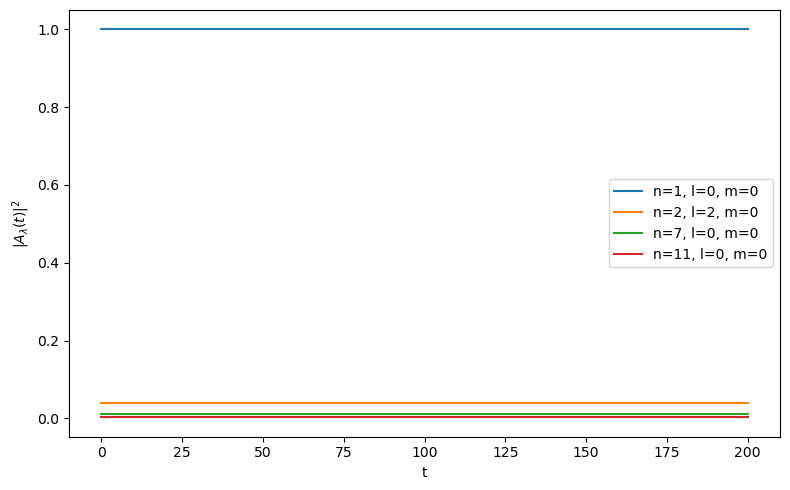

In [165]:
plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    plt.plot(t, powers[:, j], label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"$|A_\lambda(t)|^2$")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

Text(0.5, 0, 't')

Text(0, 0.5, 'fractional change in $|A_\\lambda|^2$')

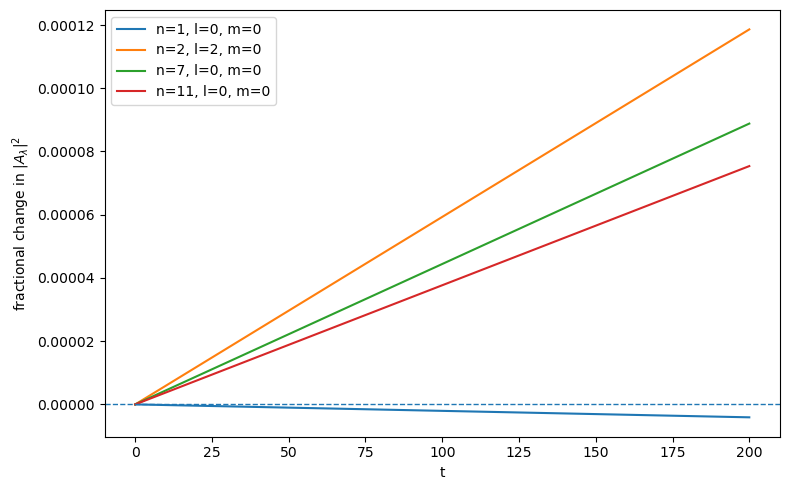

In [166]:
plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    p0 = powers[0, j]
    if p0 != 0:
        plt.plot(t, (powers[:, j] - p0) / p0, label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"fractional change in $|A_\lambda|^2$")
plt.axhline(0, linestyle="--", linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

Text(0.5, 0, 't')

Text(0, 0.5, '$\\sum_\\lambda |A_\\lambda|^2$')

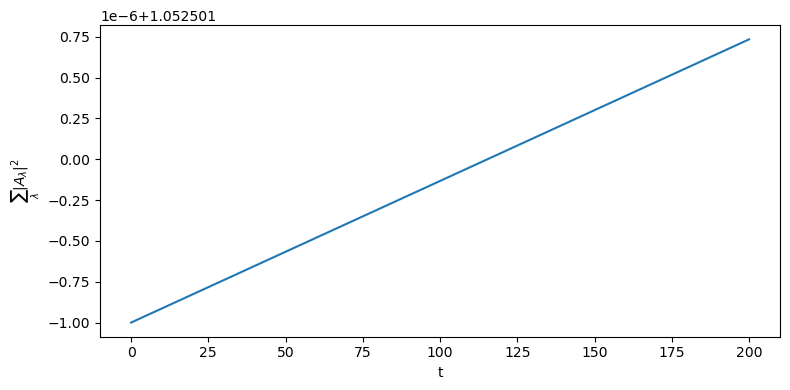

<Figure size 800x400 with 0 Axes>

Text(0.5, 0, 't')

Text(0, 0.5, 'relative total-power drift')

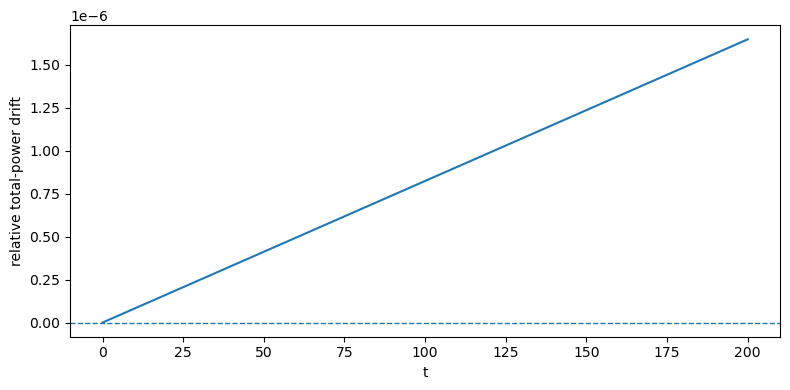

In [167]:
total_power = np.sum(powers, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(t, total_power)
plt.xlabel("t")
plt.ylabel(r"$\sum_\lambda |A_\lambda|^2$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, (total_power - total_power[0]) / total_power[0])
plt.xlabel("t")
plt.ylabel("relative total-power drift")
plt.axhline(0, linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [168]:
def hermitian_adjoint_notes(C):
    """
    Cdag[lam,i,j,k] = conjugate(C[i,lam,k,j])
    """
    return np.conjugate(np.transpose(C, (1, 0, 3, 2)))


def coupling_hermitian_defect(C, mask=None):
    if mask is None:
        mask = np.ones_like(C, dtype=bool)

    Cdag = hermitian_adjoint_notes(C)

    CH = 0.5 * (C + Cdag)
    CA = 0.5 * (C - Cdag)

    norm_H = np.linalg.norm(CH[mask])
    norm_A = np.linalg.norm(CA[mask])

    return norm_A / norm_H, norm_H, norm_A

In [169]:
eta, norm_H, norm_A = coupling_hermitian_defect(C, mask)

print("||C_antiHerm|| / ||C_Herm|| =", eta)
print("||C_Herm|| =", norm_H)
print("||C_antiHerm|| =", norm_A)

||C_antiHerm|| / ||C_Herm|| = 6.274615603101593
||C_Herm|| = 0.006440152395920887
||C_antiHerm|| = 0.04040948070979731


In [170]:
def total_action(A):
    return np.sum(np.abs(A)**2)


def Ndot_notes(t, A, eps, C, Omega, mask=None, phase_mode="real"):
    if mask is None:
        mask = 1.0

    if phase_mode == "exact":
        phase = np.exp(1j * Omega * t)
    elif phase_mode == "real":
        phase = np.exp(1j * np.real(Omega) * t)
    elif phase_mode == "resonant":
        phase = 1.0
    else:
        raise ValueError("phase_mode must be 'exact', 'real', or 'resonant'.")

    F = np.einsum(
        "lijk,i,j,k->l",
        C * mask * phase,
        A,
        A,
        np.conjugate(A),
        optimize=True,
    )

    Z = np.vdot(A, F)  # sum_l conjugate(A_l) F_l

    return 2 * eps**2 * np.imag(Z)

<Figure size 800x400 with 0 Axes>

Text(0.5, 0, 't')

Text(0, 0.5, '$\\dot N$')

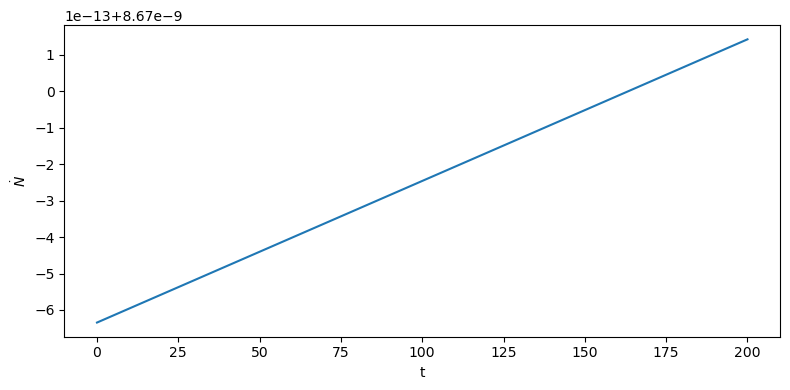

<Figure size 800x400 with 0 Axes>

Text(0.5, 0, 't')

Text(0, 0.5, 'relative drift in $N$')

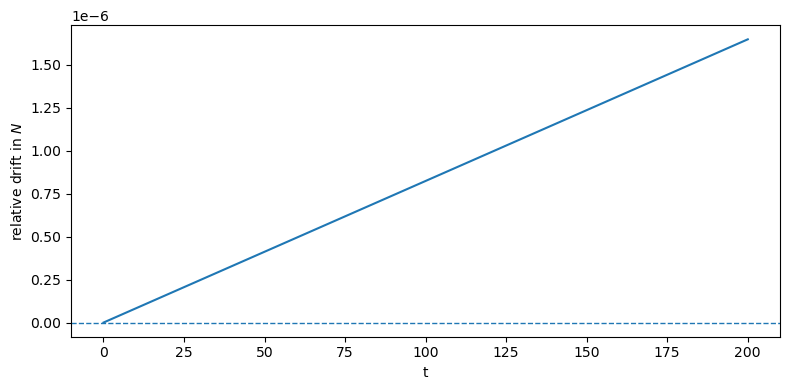

In [171]:
A_of_t = sol.y.T
Ndots = np.array([
    Ndot_notes(ti, Ai, eps, C, Omega, mask, phase_mode="exact")
    for ti, Ai in zip(sol.t, A_of_t)
])

Ntot = np.sum(np.abs(A_of_t)**2, axis=1)

plt.figure(figsize=(8,4))
plt.plot(sol.t, Ndots)
plt.xlabel("t")
plt.ylabel(r"$\dot N$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(sol.t, (Ntot - Ntot[0]) / Ntot[0])
plt.xlabel("t")
plt.ylabel(r"relative drift in $N$")
plt.axhline(0, linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [172]:
Ntot = np.sum(np.abs(sol.y.T)**2, axis=1)
relN = (Ntot - Ntot[0]) / Ntot[0]

slope, intercept = np.polyfit(sol.t, relN, 1)

print("relative drift slope =", slope)
print("relative drift at final time =", relN[-1])

relative drift slope = 8.237296011732789e-09
relative drift at final time = 1.6474592021545034e-06


In [173]:
Cdag = np.conjugate(np.transpose(C, (1, 0, 3, 2)))
C_H = 0.5 * (C + Cdag)
C_A = 0.5 * (C - Cdag)

print("relative anti-Hermitian defect =", np.linalg.norm(C_A[mask]) / np.linalg.norm(C_H[mask]))

relative anti-Hermitian defect = 6.274615603101593


In [174]:
eps_values = [0.025, 0.05, 0.1]
drifts = []

for ep in eps_values:
    sol_ep, omega_tilde_ep, Omega_ep, mask_ep = integrate_A_notes(
        A0,
        T,
        ep,
        omega_arr,
        C,
        nout=1000,
        remove_diag=True,
        include_frequency_shift=True,
        phase_mode="real",
    )

    P_ep = np.abs(sol_ep.y.T)**2
    N_ep = np.sum(P_ep, axis=1)
    drifts.append((N_ep[-1] - N_ep[0]) / N_ep[0])

for ep, drift in zip(eps_values, drifts):
    print(ep, drift, "drift/eps^2 =", drift / ep**2)

0.025 4.118509553454893e-07 drift/eps^2 = 0.0006589615285527827
0.05 1.6474592021545034e-06 drift/eps^2 = 0.0006589836808618012
0.1 6.590722777140102e-06 drift/eps^2 = 0.0006590722777140101


In [175]:
def physical_from_A_solution(sol, omega_arr, eps=1.0, include_eps=False):
    """
    Reconstruct physical/softened amplitudes

        a_lam(t) = eps A_lam(t) exp(-i omega_lam t).

    If include_eps=False, returns A_lam exp(-i omega_lam t),
    matching Mathematica's genInterpsWithSoftener convention up to eps.
    """

    t = sol.t
    A = sol.y.T

    soft = np.exp(-1j * omega_arr[None, :] * t[:, None])

    if include_eps:
        return t, eps * A * soft

    return t, A * soft

<Figure size 800x500 with 0 Axes>

Text(0.5, 0, 't')

Text(0, 0.5, '$|A_\\lambda e^{-i\\omega_\\lambda t}|$')

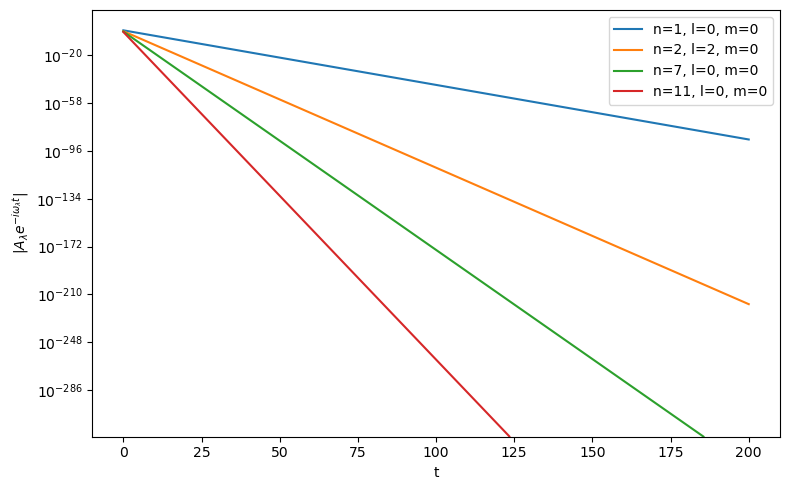

In [176]:
t, a_phys = physical_from_A_solution(sol, omega_arr, eps=eps, include_eps=False)

plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    plt.semilogy(t, np.abs(a_phys[:, j]), label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"$|A_\lambda e^{-i\omega_\lambda t}|$")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

Text(0.5, 0, 't')

Text(0, 0.5, '$|A_\\lambda e^{-i\\omega_\\lambda t}|^2$')

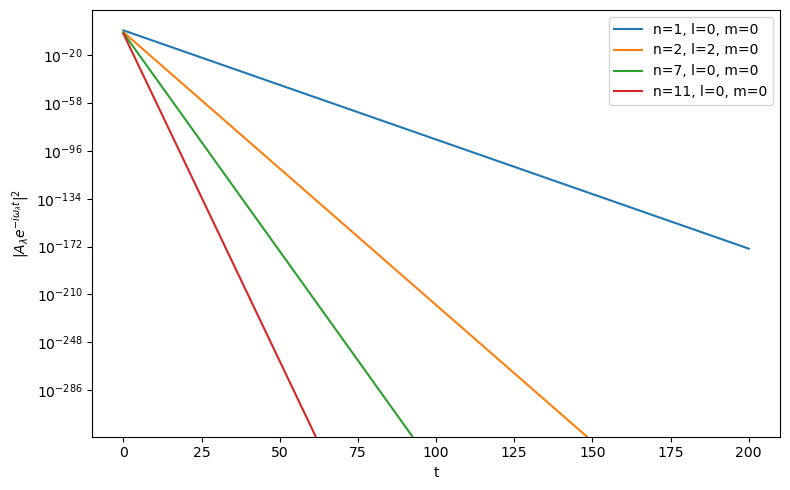

modewise comparison at final time:

n=1, l=0, m=0
  numerical: (1.0000013147572284+2.5751078939681216e-05j)
  pert:      (nan+nanj)
  diff:      (nan+nanj)
  rel diff:  nan

n=2, l=2, m=0
  numerical: (0.19106465481078522+0.059163839551422015j)
  pert:      (nan+nanj)
  diff:      (nan+nanj)
  rel diff:  nan

n=7, l=0, m=0
  numerical: (0.19600915220497447+0.7120254117651413j)
  pert:      (nan+nanj)
  diff:      (nan+nanj)
  rel diff:  nan

n=11, l=0, m=0
  numerical: (-1.8712986540109595-639.2883042666776j)
  pert:      (nan+nanj)
  diff:      (nan+nanj)
  rel diff:  nan


In [177]:
plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    plt.semilogy(t, np.abs(a_phys[:, j])**2, label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"$|A_\lambda e^{-i\omega_\lambda t}|^2$")
plt.legend()
plt.tight_layout()
plt.show()
print("modewise comparison at final time:")

for j, k in enumerate(modes):
    print()
    print(mode_label(k))
    print("  numerical:", A_num_T[j])
    print("  pert:     ", A_pert_T[j])
    print("  diff:     ", A_num_T[j] - A_pert_T[j])
    if abs(A_num_T[j]) > 0:
        print("  rel diff: ", abs(A_num_T[j] - A_pert_T[j]) / abs(A_num_T[j]))

In [178]:
Cdag = np.conjugate(np.transpose(C, (1, 0, 3, 2)))
C_H = 0.5 * (C + Cdag)
C_A = 0.5 * (C - Cdag)

sol_H, omega_tilde_H, Omega_H, mask_H = integrate_A_notes(
    A0,
    T,
    0.05,
    omega_arr,
    C_H,
    nout=1000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
)

P_H = np.abs(sol_H.y.T)**2
N_H = np.sum(P_H, axis=1)

print("Hermitian projected drift =",
      (N_H[-1] - N_H[0]) / N_H[0])

Hermitian projected drift = 2.1096874577200126e-16


In [179]:
shift = omega_shift_notes(A0, C)

print("frequency-shift real part:")
print(np.real(shift))

print("nonlinear damping/growth from imaginary part:")
print(np.imag(shift))

frequency-shift real part:
[-1.56272990e-05 -5.23650137e-06 -3.39156226e-06 -4.41300956e-04]
nonlinear damping/growth from imaginary part:
[-0.00095129 -0.00027737 -0.00024388 -0.00651709]
